In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the processed data from Phase 3 — we don't repeat preprocessing here,
# we trust the saved output, which is the whole point of separating phases
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5285, 20)
X_test shape: (1322, 20)


4.3 — Train the Model

In [2]:
# Step 1: Create the model object (untrained at this point)
model = LinearRegression()

# Step 2: Train it — this is where the weight-finding math actually happens
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [3]:
# Inspect what the model learned
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("Intercept (b):", model.intercept_)
coefficients

Intercept (b): 67.2151371807001


,Feature,Coefficient
1,Attendance,2.292315
0,Hours_Studied,1.758266
3,Access_to_Resources,0.733153
5,Previous_Scores,0.712903
2,Parental_Involvement,0.701046
7,Tutoring_Sessions,0.614828
17,Peer_Influence_Positive,0.515946
8,Family_Income,0.400216
11,Parental_Education_Level,0.373166
6,Motivation_Level,0.362000


4.4 — Make Predictions


In [4]:
y_pred = model.predict(X_test)

# Compare a few actual vs predicted values
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10].round(2)
})
comparison

,Actual,Predicted
0,65,64.63
1,65,65.37
2,71,71.51
3,64,64.23
4,66,66.52
5,66,66.65
6,72,72.22
7,66,66.35
8,70,69.93
9,70,70.01


4.5 — Evaluation Metrics (Theory + Code)

In [5]:
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f}")

MAE: 0.46


MSE — Mean Squared Error

In [6]:
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.2f}")

MSE: 3.26


RMSE — Root Mean Squared Error

In [7]:
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

RMSE: 1.81


R² Score — Coefficient of Determination

In [8]:
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.7691


In [9]:
# Summary table
results_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Value': [mae, mse, rmse, r2]
})
results_df

,Metric,Value
0,MAE,0.463224
1,MSE,3.264179
2,RMSE,1.806704
3,R² Score,0.769072


4.6 — Visualize Model Performance

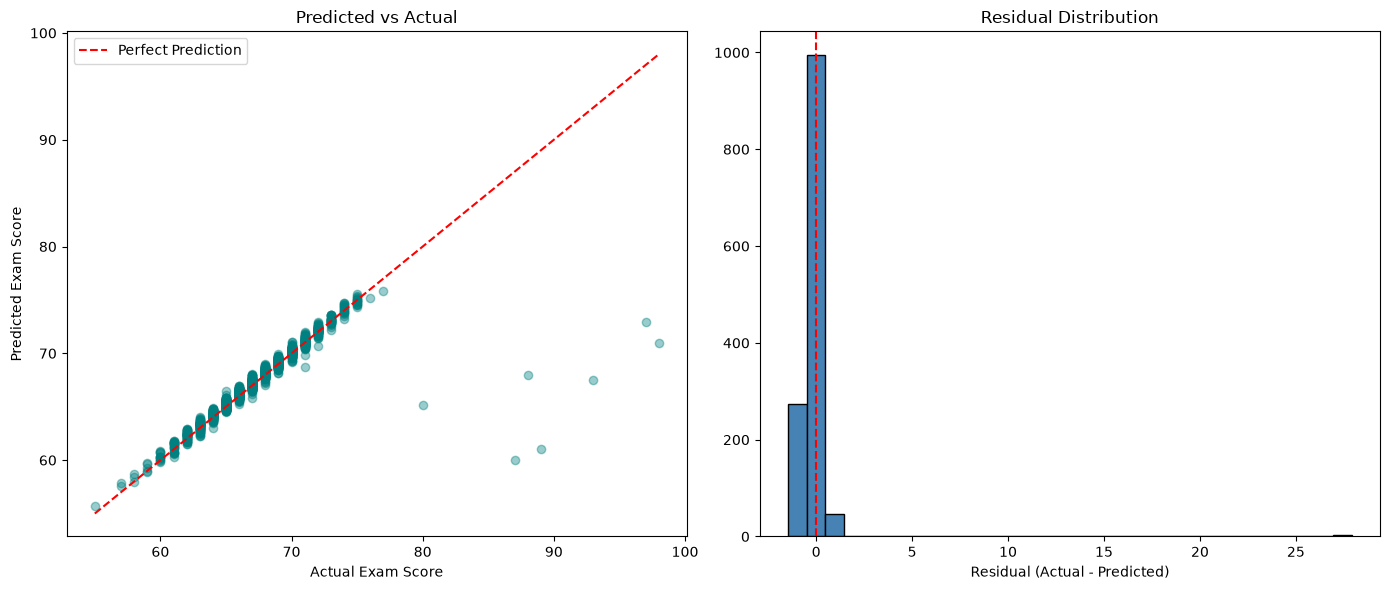

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.4, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             color='red', linestyle='--', label='Perfect Prediction')
axes[0].set_xlabel('Actual Exam Score')
axes[0].set_ylabel('Predicted Exam Score')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# Plot 2: Residuals (errors) distribution
residuals = y_test - y_pred
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

4.7 — Sanity-Check Baseline

In [11]:
# Compare against the "dumbest possible model" — always predict the mean
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_r2 = r2_score(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Baseline (mean-only) R²: {baseline_r2:.4f}  (should be ~0)")
print(f"Baseline (mean-only) MAE: {baseline_mae:.2f}")
print(f"Our model's R²:  {r2:.4f}")
print(f"Our model's MAE: {mae:.2f}")

Baseline (mean-only) R²: -0.0007  (should be ~0)
Baseline (mean-only) MAE: 2.82
Our model's R²:  0.7691
Our model's MAE: 0.46


Model improvement

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed — skipping. Run: pip install xgboost")

5.2 — Model 1: Decision Tree Regressor

In [15]:
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print(f"Decision Tree — MAE: {dt_mae:.2f}, RMSE: {dt_rmse:.2f}, R²: {dt_r2:.4f}")

Decision Tree — MAE: 1.64, RMSE: 2.67, R²: 0.4955


5.3 — Model 2: Random Forest Regressor

In [16]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest — MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}, R²: {rf_r2:.4f}")

Random Forest — MAE: 1.14, RMSE: 2.19, R²: 0.6617


5.4 — Model 3: XGBoost Regressor (if available)

In [17]:
if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
    xgb_model.fit(X_train, y_train)

    xgb_pred = xgb_model.predict(X_test)

    xgb_mae = mean_absolute_error(y_test, xgb_pred)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
    xgb_r2 = r2_score(y_test, xgb_pred)

    print(f"XGBoost — MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}, R²: {xgb_r2:.4f}")
else:
    print("Skipped — XGBoost not installed")

XGBoost — MAE: 0.82, RMSE: 2.06, R²: 0.6987


5.5 — Compare All Models

In [18]:
results = {
    'Linear Regression': {'MAE': mae, 'RMSE': rmse, 'R2': r2},
    'Decision Tree': {'MAE': dt_mae, 'RMSE': dt_rmse, 'R2': dt_r2},
    'Random Forest': {'MAE': rf_mae, 'RMSE': rf_rmse, 'R2': rf_r2},
}

if XGBOOST_AVAILABLE:
    results['XGBoost'] = {'MAE': xgb_mae, 'RMSE': xgb_rmse, 'R2': xgb_r2}

comparison_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
comparison_df

,MAE,RMSE,R2
Linear Regression,0.463224,1.806704,0.769072
XGBoost,0.821132,2.063674,0.698711
Random Forest,1.139374,2.186852,0.661670
Decision Tree,1.637923,2.670406,0.495505


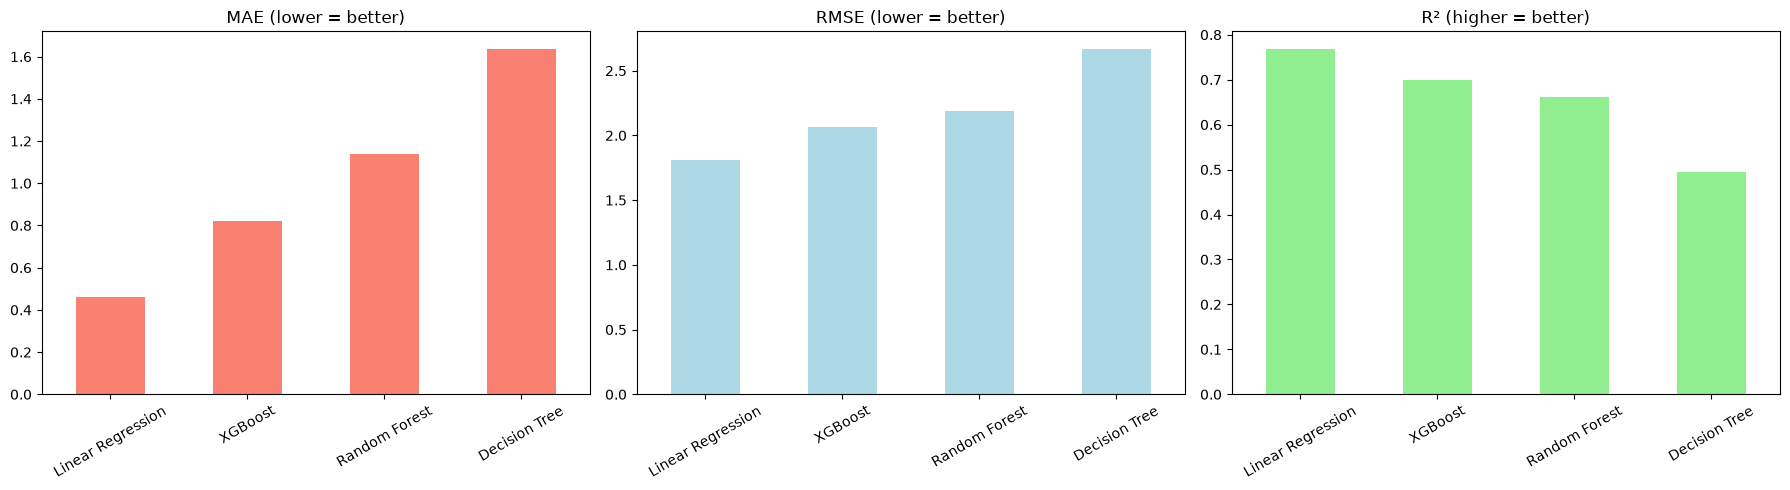

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparison_df['MAE'].plot(kind='bar', ax=axes[0], color='salmon', title='MAE (lower = better)')
comparison_df['RMSE'].plot(kind='bar', ax=axes[1], color='lightblue', title='RMSE (lower = better)')
comparison_df['R2'].plot(kind='bar', ax=axes[2], color='lightgreen', title='R² (higher = better)')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

5.6 — Feature Importance (Random Forest)

C:\Users\MC USER\AppData\Local\Temp\ipykernel_27852\1347694056.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')


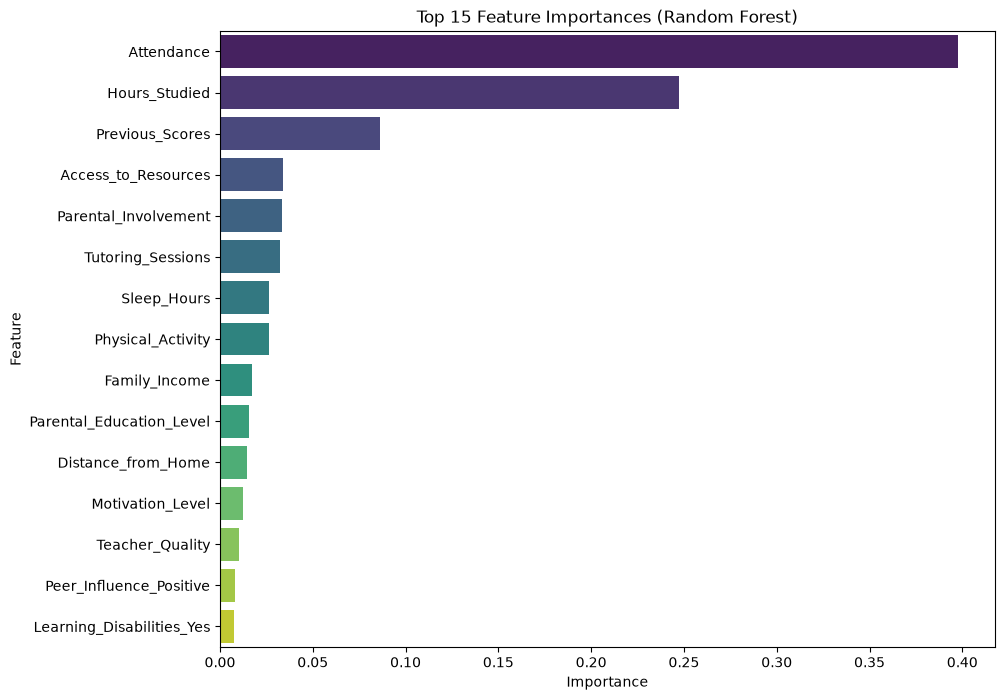

,Feature,Importance
1,Attendance,0.397713
0,Hours_Studied,0.247461
5,Previous_Scores,0.086057
3,Access_to_Resources,0.033694
2,Parental_Involvement,0.033532
7,Tutoring_Sessions,0.032563
4,Sleep_Hours,0.026357
10,Physical_Activity,0.026259
8,Family_Income,0.017508
11,Parental_Education_Level,0.015521


In [20]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.show()

importances.head(10)

5.7 — Choosing the Best Model

In [21]:
best_model_name = comparison_df['R2'].idxmax()
print(f"Best model by R²: {best_model_name}")
print(comparison_df.loc[best_model_name])

Best model by R²: Linear Regression
MAE     0.463224
RMSE    1.806704
R2      0.769072
Name: Linear Regression, dtype: float64


Model Saving

In [46]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

6.2 — Select and Save the Winning Model

In [47]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

model_mapping = {
    'Linear Regression': (model, 'linear_regression'),
    'Decision Tree': (dt_model, 'decision_tree'),
    'Random Forest': (rf_model, 'random_forest'),
}
if XGBOOST_AVAILABLE:
    model_mapping['XGBoost'] = (xgb_model, 'xgboost')

best_model_key = comparison_df['R2'].idxmax()
best_model, best_model_name = model_mapping[best_model_key]

# Clean up any existing model files in /models to prevent old models from being loaded
import glob
for f in glob.glob('../models/*_model.pkl'):
    try:
        os.remove(f)
    except:
        pass

joblib.dump(best_model, f'../models/{best_model_name}_model.pkl')
print(f"Best model ({best_model_key}) saved to ../models/{best_model_name}_model.pkl")


Best model (Linear Regression) saved to ../models/linear_regression_model.pkl



6.3 — Save Preprocessing Objects

In [48]:
# Load the preprocessing objects from Phase 3
import joblib
import json

scaler = joblib.load('../models/scaler.pkl')
with open('../models/ordinal_mappings.json', 'r') as f:
    ordinal_cols = json.load(f)
training_columns = list(X_train.columns)

print("Preprocessing objects loaded successfully:")
print("  - scaler.pkl")
print("  - ordinal_mappings.json")
print("  - training_columns.json")


Preprocessing objects loaded successfully:
  - scaler.pkl
  - ordinal_mappings.json
  - training_columns.json


Build a Reusable Prediction Function

In [49]:
def predict_exam_score(raw_input: dict, model, scaler, ordinal_mappings, training_columns):
    """
    Takes a dictionary of raw student feature values and returns a predicted exam score.

    Parameters:
        raw_input: dict, e.g., {'Hours_Studied': 12, 'Attendance': 85, ...}
        model: trained sklearn model
        scaler: fitted StandardScaler from training
        ordinal_mappings: dict of {column: [ordered categories]}
        training_columns: list of column names model was trained on

    Returns:
        float: predicted exam score
    """
    # Step 1: Convert input dict to a single-row DataFrame
    input_df = pd.DataFrame([raw_input])

    # Step 2: Apply ordinal encoding (same logic as Phase 3.5)
    for col, order in ordinal_mappings.items():
        if col in input_df.columns:
            mapping = {category: i for i, category in enumerate(order)}
            input_df[col] = input_df[col].map(mapping)

    # Step 3: Apply one-hot encoding for nominal columns present in input
    input_df = pd.get_dummies(input_df)

    # Step 4: Align columns to match training data exactly
    # Any column the model expects but isn't in this input gets filled with 0
    # Any extra column not seen during training gets dropped
    input_df = input_df.reindex(columns=training_columns, fill_value=0)

    # Step 5: Scale using the SAME scaler fitted during training
    input_scaled = scaler.transform(input_df)

    # Step 6: Predict
    input_scaled_df = pd.DataFrame(input_scaled, columns=input_df.columns)
    prediction = model.predict(input_scaled_df)[0]

    return round(prediction, 2)

In [50]:
sample_input = {
    'Hours_Studied': 15,
    'Attendance': 88,
    'Parental_Involvement': 'High',
    'Access_to_Resources': 'Medium',
    'Extracurricular_Activities': 'Yes',
    'Sleep_Hours': 7,
    'Previous_Scores': 75,
    'Motivation_Level': 'Medium',
    'Internet_Access': 'Yes',
    'Tutoring_Sessions': 2,
    'Family_Income': 'Medium',
    'Teacher_Quality': 'High',
    'School_Type': 'Public',
    'Peer_Influence': 'Positive',
    'Physical_Activity': 3,
    'Learning_Disabilities': 'No',
    'Parental_Education_Level': 'College',
    'Distance_from_Home': 'Near',
    'Gender': 'Male'
}

predicted_score = predict_exam_score(sample_input, best_model, scaler, ordinal_cols, training_columns)
print(f"Predicted Exam Score: {predicted_score}")

Predicted Exam Score: 68.79


d:\student-exam-marks-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
